# Quantization Aware Training + Knowledge Distillation 
## PyTorch -> ONNX -> TfLite

In [ ]:
import os
import torch

from model_compression.src.utils import load_data, process_callbacks
from model_compression.src.converters.to_onnx import export_pytorch_to_onnx, export_onnx_to_savedmodel, export_savedmodel_to_tflite
from model_compression.src.train.knowledge_distillation import train_kd
from model_compression.src.utils.logging_setup import configure_logging
from model_compression.src.converters.to_tflite import convert_pytorch_model_to_tflite

2025-05-05 17:33:17.255360: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-05 17:33:17.263726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746480797.272712   18580 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746480797.275433   18580 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1746480797.283360   18580 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

configure_logging(True)

### Hyperparameters

[INFO 2025-05-05 17:33:19,581 preprocessing.py:44] Train size: 29322
[INFO 2025-05-05 17:33:19,581 preprocessing.py:47]   Class 'Actinic keratoses': 693 samples
[INFO 2025-05-05 17:33:19,581 preprocessing.py:47]   Class 'Basal cell carcinoma': 2658 samples
[INFO 2025-05-05 17:33:19,581 preprocessing.py:47]   Class 'Benign keratosis-like lesions': 2099 samples
[INFO 2025-05-05 17:33:19,582 preprocessing.py:47]   Class 'Chickenpox': 900 samples
[INFO 2025-05-05 17:33:19,582 preprocessing.py:47]   Class 'Cowpox': 792 samples
[INFO 2025-05-05 17:33:19,582 preprocessing.py:47]   Class 'Dermatofibroma': 191 samples
[INFO 2025-05-05 17:33:19,582 preprocessing.py:47]   Class 'HFMD': 1932 samples
[INFO 2025-05-05 17:33:19,582 preprocessing.py:47]   Class 'Healthy': 1368 samples
[INFO 2025-05-05 17:33:19,582 preprocessing.py:47]   Class 'Measles': 660 samples
[INFO 2025-05-05 17:33:19,582 preprocessing.py:47]   Class 'Melanocytic nevi': 10300 samples
[INFO 2025-05-05 17:33:19,583 preprocessing.p

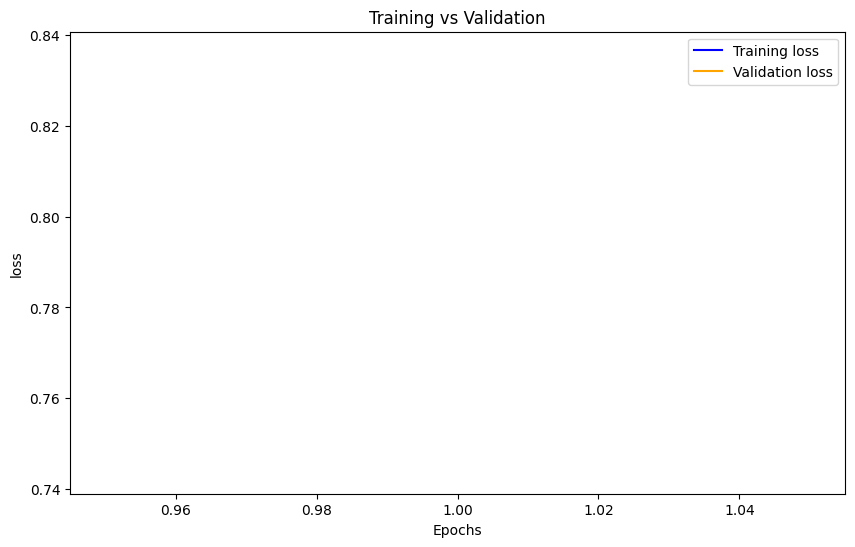

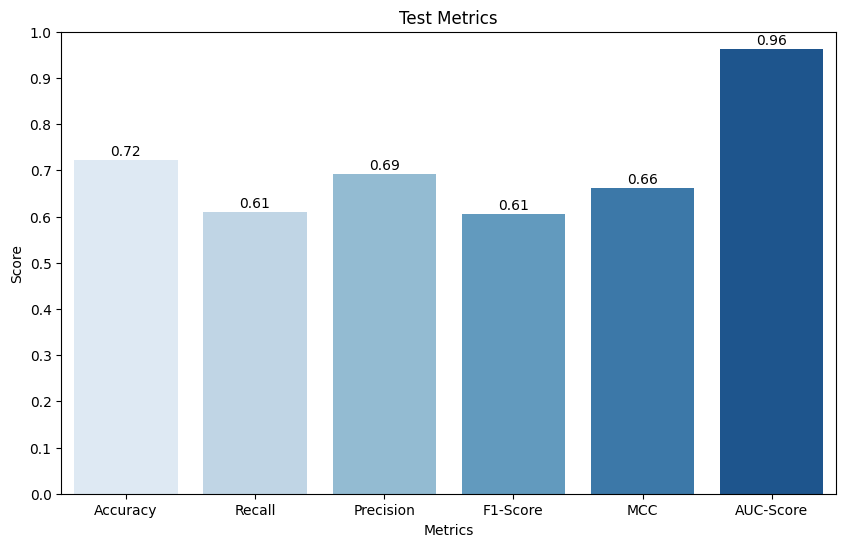

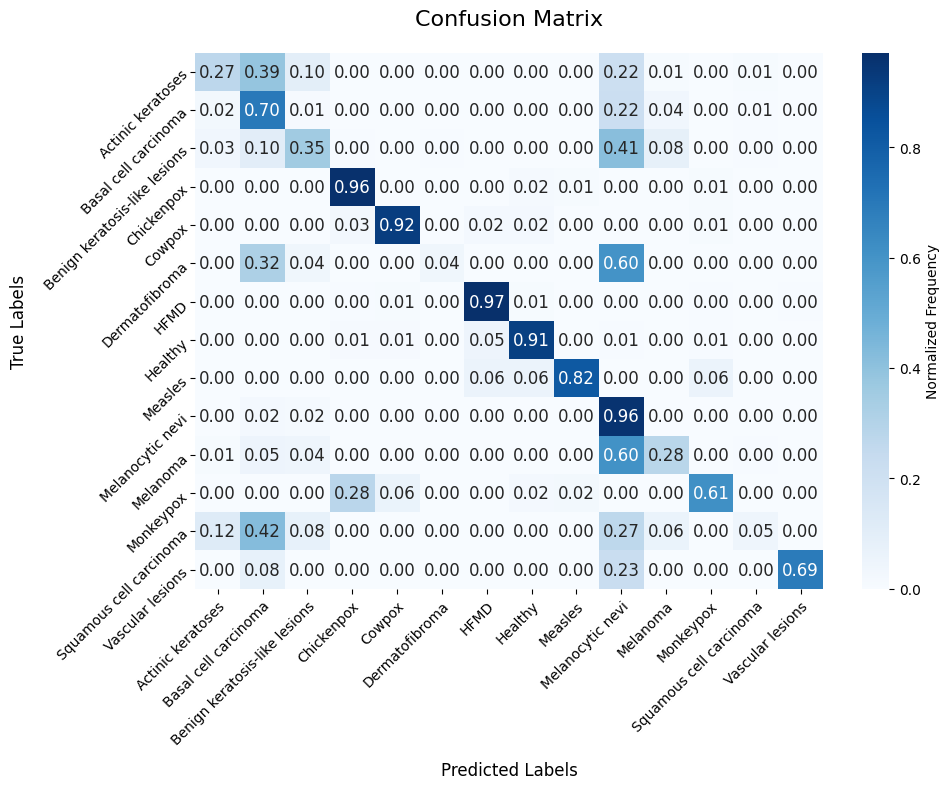

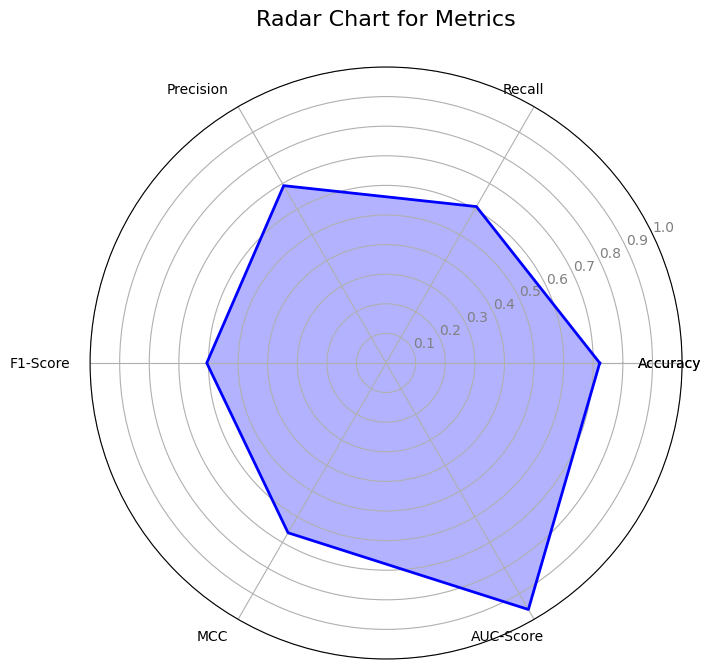

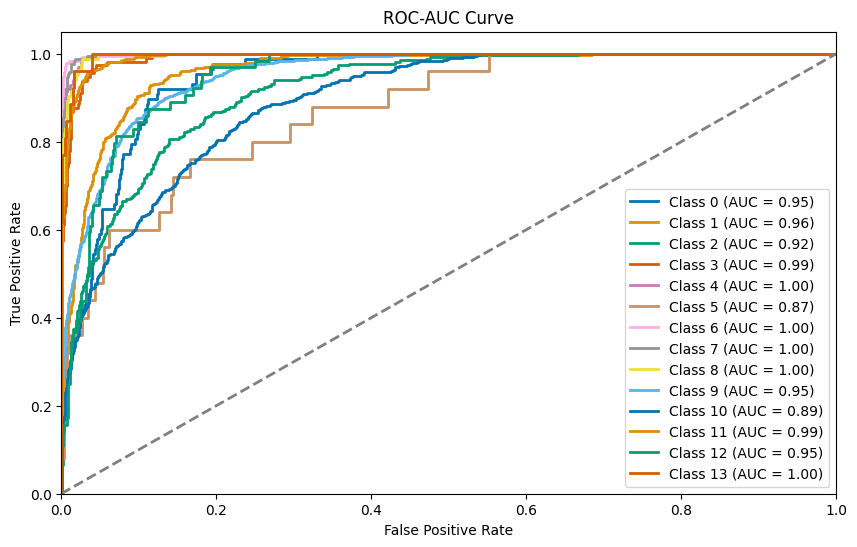

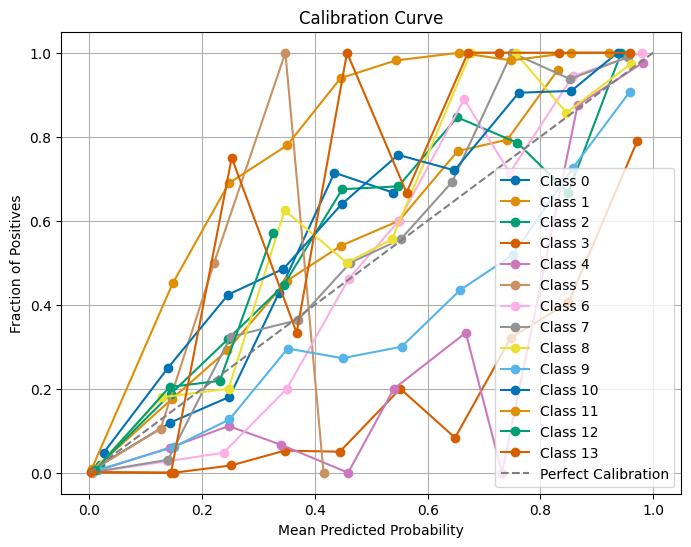

In [3]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/Quantized"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "qat_kd"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset_name=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"

teacher, quantized_student = train_kd(
                                teacher_name=teacher_model, 
                                student_name=student_model,
                                data_loaders=dataloaders,
                                save_dir=save_dir,
                                learning_rate=learning_rate,
                                num_epochs=epochs,
                                criterion_name = criterion,
                                optimizer_name = optimizer,
                                callbacks=CALLBACKS,
                                quant_mode="export",
                                teacher_weights_path=teacher_model_weights,
                                device=device,
                                )


### 2. Export to TfLite

In [ ]:
example_inputs = next(iter(dataloaders['train']))[0].to(device)
tflite_path = os.path.join(save_dir, f"{student_model}_kd.tflite")
# Currently fails because model_compression/src/quantization/core/quantize.py convert_pt2e(model, fold_quantize=True)
# fold_quantize=False will make the convert succeed but the model will not compress appropriately.
# fold_quantize=True is still not supported 
convert_pytorch_model_to_tflite(quantized_student, (example_inputs,), tflite_path)

### 3. Export to ONNX

In [4]:
example_inputs = next(iter(dataloaders['train']))[0]
onnx_path = os.path.join(save_dir, f"{student_model}_qat_kd.onnx")
export_pytorch_to_onnx(quantized_student.to("cpu"), example_inputs.to("cpu"), onnx_path, dynamo=True, opset_version=12)

/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/onnxscript/converter.py:823: FutureWarning: 'onnxscript.values.Op.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()
/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/onnxscript/converter.py:823: FutureWarning: 'onnxscript.values.OnnxFunction.param_schemas' is deprecated in version 0.1 and will be removed in the future. Please use '.op_signature' instead.
  param_schemas = callee.param_schemas()


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


W0505 17:37:57.646000 18580 site-packages/torch/fx/experimental/symbolic_shapes.py:6184] Ignored guard s0 >= 16 == True, this could result in accuracy problems
[INFO 2025-05-05 17:37:58,069 to_onnx.py:78] Exported model to ONNX at models/SkinCancer/Quantized/mobilenet_v2_qat_kd.onnx


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


### 3. Convert ONNX → TensorFlow SavedModel

In [7]:
save_dir = f"models/{dataset}/Quantized"
student_model = "mobilenet_v2"

In [ ]:
tf_saved_model_dir = os.path.join(save_dir, f"{student_model}_qat_kd")
onnx_path = os.path.join(save_dir, f"{student_model}_qat_kd.onnx")
export_onnx_to_savedmodel(onnx_path, tf_saved_model_dir)

### 4. Convert SavedModel → TFLite

In [ ]:
tflite_path = os.path.join(save_dir, f"{student_model}_qat_kd.tflite")
export_savedmodel_to_tflite(tf_saved_model_dir, tflite_path, dataloaders["train"])

### 5. Model sizes

In [ ]:
print(os.path.getsize("models/SkinCancer/Quantized/quantized_state.pth") / 1e6)
print(os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.onnx") / 1e6)
print(os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.tflite") / 1e6)

In [ ]:
# TODO: Try a different model from mobilenetv2
# TODO: Get weights from QAT and then use post-training quantization
# TODO: explore more optimization techniques (low-rank aproximation)
print(os.path.getsize("models/SkinCancer/Quantized/quantized_student_state.pth") / 1e6)